In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.signal import welch
import seaborn as sns
import pickle 

In [2]:
from src.model import intensity
from src.theory import lif_rate_homog, fixed_pt_iter_propagators_1pop, fixed_pt_iter_propagators_1pop_true
from src.sim import sim_lif_perturbation, sim_lif_perturbation_exp, sim_lif_pop, create_spike_train

In [3]:
# Function to take in output of simulation and return interspike-intervals

def get_isi(spktimes):
    isi = np.empty((0))
    for i in range(len(np.unique(spktimes[:,1]))):
        temp = spktimes[spktimes[:,1]==i]
        temp = np.diff(temp[:,0])
        if temp.shape[0] > 0:
            isi = np.append(isi, temp)
    return isi

In [4]:
# Funciton to take in output of simulation and return pre-spike voltages

def get_Visi(spktimes, Vs):
    Visi = np.empty((0))
    for i in range(len(np.unique(spktimes[:,1]))):
        temp = spktimes[spktimes[:,1]==i]
        temp = np.rint(temp[:,0]*100).astype(int)
        temp = Vs[:,i][temp]
        # Clip voltages at 20 to prevent voltages at ~10^68 from completely skewing variance
        temp = np.clip(temp, a_min=None, a_max=20)
        if temp.shape[0] > 0:
            Visi = np.append(Visi, temp)
    return Visi

In [5]:
fontsize = 10
labelsize = 9

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = ['k']+colors

# root_dir = '/Users/gkocker/Documents/projects/lif_stochastic'
root_dir = '/Users/micha/School/Neuro/LIF_Conductance'
results_dir = os.path.join(root_dir, 'results')

In [6]:
# Setting parameters for one run of the simulation

# Number of neurons
N = 10

# Time parameters
tstop = 50
dt = .01

# List of perturbation start times, curations, amplitudes
pstart=[0]
plen=[50]
pamp=[1]

# E_leak, E_syn, g, J
# For simulations of unconnected neurons, we set J matrix to be 0
E_l = 0.375
E_s = 0
g = 0
J = np.zeros((N,N))

# delta parameter for exponential
delta = 0.4375

In [7]:
Vs, spktimes = sim_lif_perturbation_exp(J=J, E_l=E_l, E_s=E_s, tstop=tstop, dt=dt, delta=delta, perturb_starts=pstart, perturb_lens=plen, perturb_amps=pamp)

(10,)


c:\Users\micha\School\Neuro\venv\Lib\site-packages\src\sim.py:298: RuntimeWarning: overflow encountered in exp
  v[t] = v[t-1] + dt*(-v[t-1] + E_l + delta*np.exp((v[t-1]-v_th)/delta)) + J.dot(n) * (E_s-v[t-1])


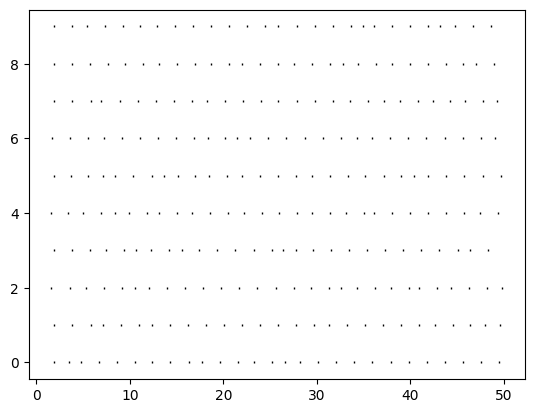

In [8]:
plt.plot(spktimes[:, 0], spktimes[:, 1], 'k|', markersize=1.5)

In [9]:
N = 10

tstop = 50
dt = .01
E = 0
pstart=[0]
plen=[50]
pamp=[0.2]

E_l = 0.375
E_s = 0
g = 0
J = np.zeros((N,N))
delta = 0.4375

runs_04375 = {}

# Now do the same sims, but looping over different values of perturbation amplitude (injected current)
# Also get the associated isi's and pre-spike voltages
for amp in np.linspace(0.5, 5.0, 45, True):
    amp = np.round(amp, 1)
    print(f'On amp: {amp}')
    pamp=[amp]
    Vs, spktimes = sim_lif_perturbation_exp(J=J, E_l=E_l, E_s=E_s, tstop=tstop, dt=dt, delta=delta, perturb_starts=pstart, perturb_lens=plen, perturb_amps=pamp)
    isi = get_isi(spktimes)
    Visi = get_Visi(spktimes, Vs)
    runs_04375[amp] = {'Vs': Vs, 'spktimes': spktimes, 'isi': isi, 'isi_var': np.var(isi), 'Visi': Visi, 'Visi_var': np.var(Visi)}

On amp: 0.5
(10,)
On amp: 0.6
(10,)
On amp: 0.7
(10,)
On amp: 0.8
(10,)
On amp: 0.9
(10,)
On amp: 1.0
(10,)
On amp: 1.1
(10,)
On amp: 1.2
(10,)
On amp: 1.3
(10,)
On amp: 1.4
(10,)
On amp: 1.5
(10,)
On amp: 1.6
(10,)
On amp: 1.7
(10,)
On amp: 1.8
(10,)
On amp: 1.9
(10,)
On amp: 2.0
(10,)
On amp: 2.1
(10,)
On amp: 2.2
(10,)
On amp: 2.3
(10,)
On amp: 2.4
(10,)
On amp: 2.5
(10,)
On amp: 2.6
(10,)
On amp: 2.8
(10,)
On amp: 2.9
(10,)
On amp: 3.0
(10,)
On amp: 3.1
(10,)
On amp: 3.2
(10,)
On amp: 3.3
(10,)
On amp: 3.4
(10,)
On amp: 3.5
(10,)
On amp: 3.6
(10,)
On amp: 3.7
(10,)
On amp: 3.8
(10,)
On amp: 3.9
(10,)
On amp: 4.0
(10,)
On amp: 4.1
(10,)
On amp: 4.2
(10,)
On amp: 4.3
(10,)
On amp: 4.4
(10,)
On amp: 4.5
(10,)
On amp: 4.6
(10,)
On amp: 4.7
(10,)
On amp: 4.8
(10,)
On amp: 4.9
(10,)
On amp: 5.0
(10,)


In [10]:
# Collect all isi's and pre-spike voltages
vars_isi = []
vars_Vs = []
inject = []
for key in runs_04375.keys():
    inject.append(key)
    vars_isi.append(runs_04375[key]['isi_var'])
    vars_Vs.append(runs_04375[key]['Visi_var'])

Text(0.5, 0, 'Injected Current')

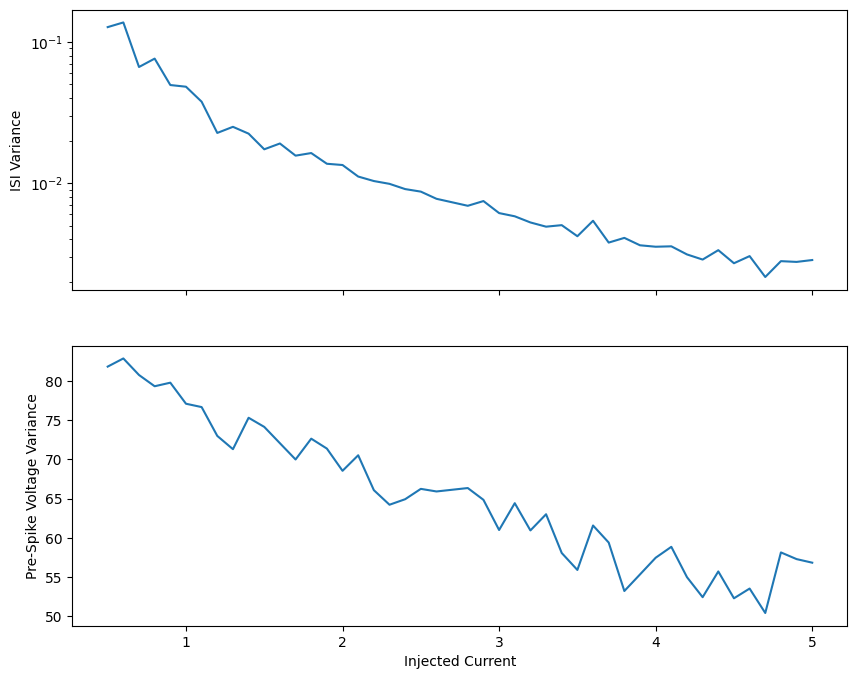

In [11]:
# Plot
fig, axs = plt.subplots(2, sharex=True, figsize=(10,8))

axs[0].plot(inject, vars_isi)
axs[0].set_yscale('log')
axs[0].set_ylabel('ISI Variance')

axs[1].plot(inject, vars_Vs)
axs[1].set_ylabel('Pre-Spike Voltage Variance')
axs[1].set_xlabel('Injected Current')

In [ ]:
fig.savefig(os.path.join(results_dir, 'runs_delta04375_isi_var.png'), dpi=200)

In [ ]:
with open(os.path.join(results_dir, 'runs_delta04375.pkl'), 'wb') as f:
    pickle.dump(runs_04375, f)

In [12]:
# Do the same thing but across different values of delta

N = 10

tstop = 50
dt = .01
E = 0
pstart=[0]
plen=[50]
pamp=[2.0]

E_l = 0.375
E_s = 0
g = 0
J = np.zeros((N,N))
delta = 0.4375

runs_2 = {}

for delt in np.linspace(0.05, 2.0, 40, True):
    delta = round(delt, 2)
    print(f'On delta: {delta}')
    Vs, spktimes = sim_lif_perturbation_exp(J=J, E_l=E_l, E_s=E_s, tstop=tstop, dt=dt, delta=delta, perturb_starts=pstart, perturb_lens=plen, perturb_amps=pamp)
    isi = get_isi(spktimes)
    Visi = get_Visi(spktimes, Vs)
    runs_2[delta] = {'Vs': Vs, 'spktimes': spktimes, 'isi': isi, 'isi_var': np.var(isi), 'Visi': Visi, 'Visi_var': np.var(Visi)}

On delta: 0.05
(10,)
On delta: 0.1
(10,)
On delta: 0.15
(10,)
On delta: 0.2
(10,)
On delta: 0.25
(10,)
On delta: 0.3
(10,)
On delta: 0.35
(10,)
On delta: 0.4
(10,)
On delta: 0.45
(10,)
On delta: 0.5
(10,)
On delta: 0.55
(10,)
On delta: 0.6
(10,)
On delta: 0.65
(10,)
On delta: 0.7
(10,)
On delta: 0.75
(10,)
On delta: 0.8
(10,)
On delta: 0.85
(10,)
On delta: 0.9
(10,)
On delta: 0.95
(10,)
On delta: 1.0
(10,)
On delta: 1.05
(10,)
On delta: 1.1
(10,)
On delta: 1.15
(10,)
On delta: 1.2
(10,)
On delta: 1.25
(10,)
On delta: 1.3
(10,)
On delta: 1.35
(10,)
On delta: 1.4
(10,)
On delta: 1.45
(10,)
On delta: 1.5
(10,)
On delta: 1.55
(10,)
On delta: 1.6
(10,)
On delta: 1.65
(10,)
On delta: 1.7
(10,)
On delta: 1.75
(10,)
On delta: 1.8
(10,)
On delta: 1.85
(10,)
On delta: 1.9
(10,)
On delta: 1.95
(10,)
On delta: 2.0
(10,)


In [13]:
vars_isi = []
vars_Vs = []
inject = []
for key in runs_2.keys():
    inject.append(key)
    vars_isi.append(runs_2[key]['isi_var'])
    vars_Vs.append(runs_2[key]['Visi_var'])

Text(0.5, 0, 'Delta')

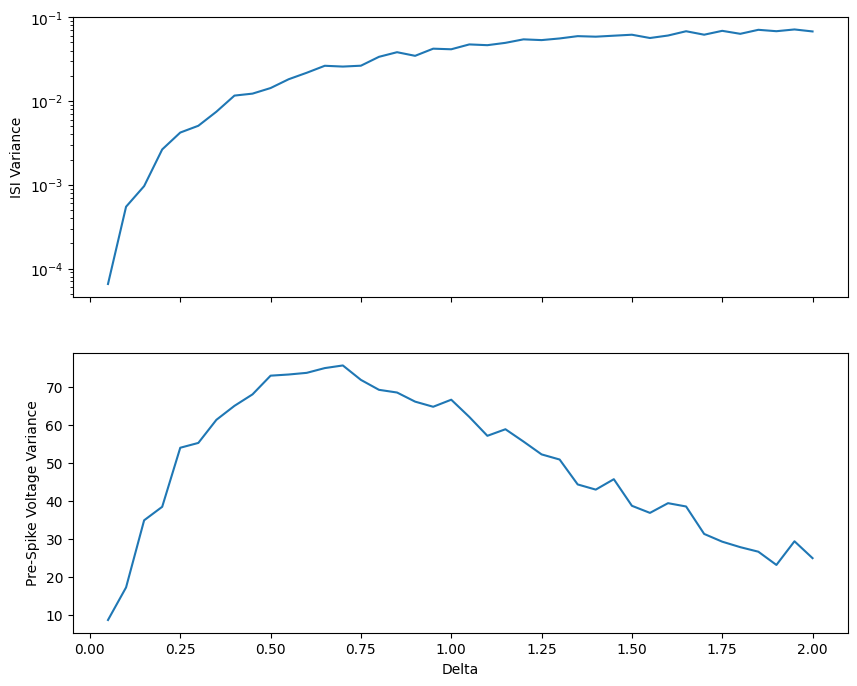

In [14]:
fig, axs = plt.subplots(2, sharex=True, figsize=(10,8))

axs[0].plot(inject, vars_isi)
axs[0].set_yscale('log')
axs[0].set_ylabel('ISI Variance')

axs[1].plot(inject, vars_Vs)
axs[1].set_ylabel('Pre-Spike Voltage Variance')
axs[1].set_xlabel('Delta')

In [ ]:
fig.savefig(os.path.join(results_dir, 'runs_I2_isi_var.png'), dpi=200)

In [ ]:
with open(os.path.join(results_dir, 'runs_I2.pkl'), 'wb') as f:
    pickle.dump(runs_04375, f)